In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from rdkit.Chem import MolFromSmiles
from rdkit.Chem.Draw import MolsToGridImage

import sys
sys.path.append('../')
import FragShapley

/home/jannik/Documents/studies/phd/03_work/20_FragShapley/FragShapley/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.style.use('style.mplstyle')
sns.set_context('talk', font_scale=1.0)
fig_folder = os.path.abspath("figures/")

In [3]:
models = ['RF', 'GCN', 'MPNN']

In [4]:
# only select a single dataset
dataset_of_interest = 'SARS'
# consider dummy atoms
remove_dummies = False

files = [f'../5_potency/{model.lower()}_regression_potency/df_explanation.pkl' for model in models]
df_pot = pd.concat((pd.read_pickle(mut_file) for mut_file in files))

df_pot = df_pot.loc[df_pot.dataset == dataset_of_interest]

In [5]:
df_pot['fragments'] = df_pot.smiles.apply(lambda x: FragShapley.utils.get_BRICS_fragments_as_SMILES(x, remove_dummies=remove_dummies))

In [6]:
# get the values of the Explainer as a list (currently only available as dict)
df_pot['fragExplainer_shapley_values'] = df_pot.fragExplainer_result.apply(lambda x: list(x.values()))
# create a dataframe of all fragments (contains duplicates) and the corresponding Shapley Value
df_fragments = df_pot[['fragments', 'model', 'fragExplainer_shapley_values']].explode(['fragments', 'fragExplainer_shapley_values'], ignore_index=True)

In [7]:
df_fragments = df_fragments.groupby(['fragments', 'model']).agg([len, 'mean', 'std', list]) # will throw warning veacuse of error when calculating std for a single measurement
df_fragments = df_fragments.reset_index() # reset so that 'fragments' is a column again and no longer the index
df_fragments.columns = [col[0] if col[1]=='' else col[1] for col in df_fragments.columns.values] # rename, choose 'fragments' for first column, for the other simply len, mean, std
df_fragments

,fragments,model,len,mean,std,list
0,*C(*)=O,GCN,9,0.135497,0.114709,"[0.08212503592173263, -0.002354571554396087, 0..."
1,*C(*)=O,MPNN,9,-0.529985,0.443798,"[-0.19927641550699865, -0.9493766396764732, -0..."
2,*C(*)=O,RF,9,0.012202,0.018669,"[0.003847759589947512, 0.00472315355725646, 0...."
3,*C(=O)C=C,GCN,3,-0.065035,0.059204,"[-0.13338632924216123, -0.029761427924746557, ..."
4,*C(=O)C=C,MPNN,3,-0.723723,0.225707,"[-0.9843467817420046, -0.5932235274996077, -0...."
...,...,...,...,...,...,...
628,*n1ccnn1,MPNN,1,-0.70948,NaN,[-0.7094801028569537]
629,*n1ccnn1,RF,1,-0.209461,NaN,[-0.20946081613756662]
630,*n1ncnn1,GCN,1,0.085617,NaN,[0.08561677932739258]
631,*n1ncnn1,MPNN,1,-0.740314,NaN,[-0.740314292907715]


In [8]:
df_fragments.query('len >= 5').sort_values(by='mean', ascending=False)

,fragments,model,len,mean,std,list
61,*CC,MPNN,10,3.967544,0.728951,"[3.5035341342290236, 3.5090204954147333, 3.798..."
79,*CC*,MPNN,26,3.934096,0.504027,"[4.151940544446309, 4.140290935834249, 3.98324..."
25,*C(C)C,MPNN,9,3.573411,0.567965,"[2.4246447245279943, 3.882554292678833, 3.8932..."
349,*[C@@H]1CCCCN1*,MPNN,17,2.559791,0.090203,"[2.240466888745626, 2.6039238373438525, 2.5914..."
373,*[C@H]1CCCN(*)C1,MPNN,16,2.530072,0.353276,"[2.412841018040975, 2.400980138778687, 2.31768..."
...,...,...,...,...,...,...
506,*c1ccncn1,RF,6,-0.368656,0.098842,"[-0.31547838277116325, -0.33891007688491936, -..."
1,*C(*)=O,MPNN,9,-0.529985,0.443798,"[-0.19927641550699865, -0.9493766396764732, -0..."
536,*c1cncc2ccccc12,RF,251,-0.618476,0.228976,"[-0.5280343344907421, -0.4698935615079371, -0...."
505,*c1ccncn1,MPNN,6,-0.732961,0.392529,"[-0.9198622567313056, -0.3355554739634195, -1...."


In [9]:
min_n = 3
mols_per_row = 5

top_k = 1 * mols_per_row

all_smiles = []
all_avg_contributions = []

for model in models:
    df_tmp = df_fragments.loc[df_fragments.model == model]
    df_tmp = df_tmp.sort_values(by='mean', ascending=False)
    df_tmp = df_tmp.loc[df_tmp.len >= min_n]
    smiles = df_tmp.iloc[:top_k].fragments.to_list()
    avg_contribution = df_tmp.iloc[:top_k]['mean'].to_list()
    all_smiles += smiles
    all_avg_contributions += avg_contribution
    print(f'{model}:')
    print('\t', smiles)
    print('\t', avg_contribution)

mols = [MolFromSmiles(sm) for sm in all_smiles]
svg = MolsToGridImage(mols=mols,
                      molsPerRow=mols_per_row,
                      legends=[f'{c:.2f}' for c in all_avg_contributions],
                      subImgSize=(200, 200),
                      useSVG=True)
with open(os.path.join(fig_folder, f"3_{dataset_of_interest}_fragments.svg"), "w") as f:
    f.write(svg.data)

RF:
	 ['*N1C[C@@]2(C(=O)N(*)C[C@@H]2C)c2cc(Cl)ccc2C1=O', '*[C@H]1CN(*)C(=O)[C@@]12CN(*)C(=O)c1ccc(Cl)cc12', '*[C@H]1CN(*)C(=O)[C@@]12CN(*)C(=O)c1ccc(F)cc12', '*N1C[C@@]2(C(=O)N(*)C[C@@H]2C)c2cc(F)ccc2C1=O', '*N1C[C@]2(CCN(*)C2=O)c2cc(Cl)ccc2C1=O']
	 [1.959893714497196, 1.6651924797663504, 1.5356655696598924, 1.311142399524152, 0.7810854111263372]
GCN:
	 ['*N1C[C@]2(CCN(*)C2=O)c2cc(Cl)ccc2C1=O', '*[C@H]1CN(*)C(=O)[C@@]12CN(*)C(=O)c1ccc(Cl)cc12', '*N1C[C@@]2(C(=O)N(*)C[C@@H]2C)c2cc(Cl)ccc2C1=O', '*C(F)(F)F', '*c1cccc(Cl)c1']
	 [2.296543034106966, 2.2809092903743573, 2.2714369124379648, 1.5835233153940056, 1.3986212925596548]
MPNN:
	 ['*CC', '*CC*', '*N1CCCC[C@H]1[C@H]1CCCO1', '*C(C)C', '*CC(C)C']
	 [3.9675443442662557, 3.9340963832842997, 3.7594483693440757, 3.573411387867397, 3.3375720474455086]


In [10]:
df_fragments.query('model == "GCN" and len >= 3').sort_values(by='mean', ascending=False).head(20)

,fragments,model,len,mean,std,list
315,*N1C[C@]2(CCN(*)C2=O)c2cc(Cl)ccc2C1=O,GCN,9,2.296543,0.276516,"[3.0033809440476564, 2.2756495475769043, 2.275..."
378,*[C@H]1CN(*)C(=O)[C@@]12CN(*)C(=O)c1ccc(Cl)cc12,GCN,44,2.280909,0.417046,"[2.4324843486150103, 2.3982500746136615, 2.402..."
288,*N1C[C@@]2(C(=O)N(*)C[C@@H]2C)c2cc(Cl)ccc2C1=O,GCN,29,2.271437,0.264443,"[2.659118016560872, 2.124523854255676, 2.12382..."
27,*C(F)(F)F,GCN,7,1.583523,0.464174,"[1.93072124946685, 1.93072124946685, 1.9307212..."
471,*c1cccc(Cl)c1,GCN,13,1.398621,0.297721,"[1.052448738188971, 1.2429811931791763, 1.2372..."
381,*[C@H]1CN(*)C(=O)[C@@]12CN(*)C(=O)c1ccc(F)cc12,GCN,3,1.337843,0.182748,"[1.1341521263122558, 1.391944948832194, 1.4874..."
69,*CC(C)C,GCN,3,0.995023,0.546958,"[0.36351927121480304, 1.3027070641517637, 1.31..."
291,*N1C[C@@]2(C(=O)N(*)C[C@@H]2C)c2cc(F)ccc2C1=O,GCN,35,0.751117,0.290493,"[0.6587196111679079, 0.7282772541046141, 1.367..."
45,*C1CCC1,GCN,3,0.547553,0.458996,"[0.3330722808837891, 0.2350609359287078, 1.074..."
24,*C(C)C,GCN,9,0.542567,0.234363,"[0.3472552220026652, 0.45209399859110516, 0.50..."


In [11]:
df_fragments.query('model == "RF" and len >= 3').sort_values(by='mean', ascending=False).head(20)

,fragments,model,len,mean,std,list
290,*N1C[C@@]2(C(=O)N(*)C[C@@H]2C)c2cc(Cl)ccc2C1=O,RF,29,1.959894,0.329963,"[1.182191980218857, 1.7172706349957902, 1.6284..."
380,*[C@H]1CN(*)C(=O)[C@@]12CN(*)C(=O)c1ccc(Cl)cc12,RF,44,1.665192,0.360158,"[1.2661941173791513, 1.6172065108976703, 1.765..."
383,*[C@H]1CN(*)C(=O)[C@@]12CN(*)C(=O)c1ccc(F)cc12,RF,3,1.535666,0.037600,"[1.5767187739598345, 1.5273741294793184, 1.502..."
293,*N1C[C@@]2(C(=O)N(*)C[C@@H]2C)c2cc(F)ccc2C1=O,RF,35,1.311142,0.102739,"[1.2869163879419219, 1.2214417557870376, 1.243..."
317,*N1C[C@]2(CCN(*)C2=O)c2cc(Cl)ccc2C1=O,RF,9,0.781085,0.081031,"[0.5903871789729823, 0.8666736061507986, 0.866..."
386,*[C@H]1C[C@H](C)CCN1*,RF,3,0.694461,0.049410,"[0.7515143354828017, 0.6659340211640198, 0.665..."
170,*N1CCCC[C@H]1[C@H]1CCCO1,RF,3,0.69095,0.000000,"[0.6909504431216911, 0.6909504431216911, 0.690..."
473,*c1cccc(Cl)c1,RF,13,0.415996,0.152459,"[0.24882728018278105, 0.4445938827711656, 0.46..."
131,*N1CCC(*)(C)CC1,RF,3,0.350494,0.137076,"[0.3847569488035094, 0.199536337932901, 0.4671..."
203,*N1CCN(*)[C@H]2CS(=O)(=O)C[C@H]21,RF,3,0.350127,0.009410,"[0.34612255272967757, 0.3433816980669798, 0.36..."


In [12]:
fragments_of_interest = ['*C(F)(F)F']
for f in fragments_of_interest:
    df_pot[f'contains_{f}'] = df_pot.fragments.apply(lambda x: f in x)

In [13]:
# in test set
df_pot.loc[df_pot['contains_*C(F)(F)F'] == True].query('model == "RF"').y_true.describe()

count    7.000000
mean     7.262857
std      1.499886
min      4.350000
25%      6.805000
50%      7.670000
75%      8.265000
max      8.680000
Name: y_true, dtype: float64

In [14]:
# comparing to average
df_pot.query("model == 'RF'").y_true.describe()

count    263.000000
mean       6.270000
std        1.335446
min        4.020000
25%        5.070000
50%        6.330000
75%        7.455000
max        8.730000
Name: y_true, dtype: float64

In [15]:
# check training set
df_train = pd.read_csv('../0_datasets/regression/SARS.csv')
df_train = df_train.loc[df_train.set == "Train"]

# get BRICS
df_train['fragments'] = df_train.canonical_smiles.apply(lambda x: FragShapley.utils.get_BRICS_fragments_as_SMILES(x, remove_dummies=remove_dummies))

In [16]:
for f in fragments_of_interest:
    df_train[f'contains_{f}'] = df_train.fragments.apply(lambda x: f in x)

In [17]:
# in train set
df_train.loc[df_train['contains_*C(F)(F)F'] == True].pIC50.describe()

count    28.000000
mean      5.576429
std       0.991939
min       4.130000
25%       4.750000
50%       5.430000
75%       6.180000
max       7.400000
Name: pIC50, dtype: float64

<Axes: ylabel='Density'>

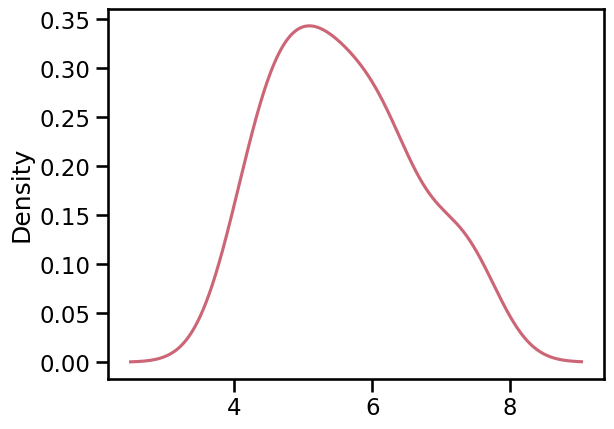

In [18]:
df_train.loc[df_train['contains_*C(F)(F)F'] == True].pIC50.plot.kde()

In [19]:
df_train.pIC50.describe()

count    842.000000
mean       5.316734
std        1.005152
min        4.000000
25%        4.510000
50%        5.095000
75%        5.887500
max        8.680000
Name: pIC50, dtype: float64

<Axes: ylabel='Density'>

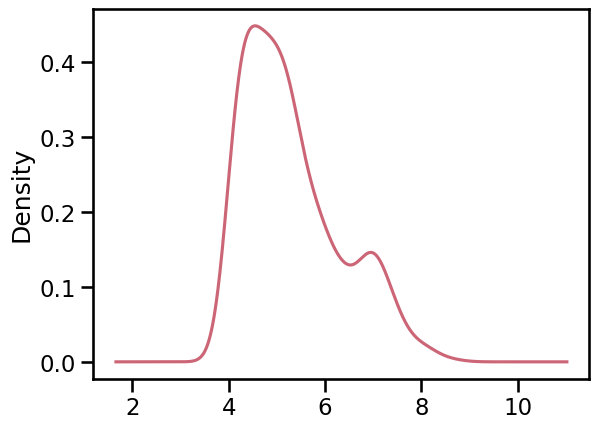

In [20]:
df_train.pIC50.plot.kde()

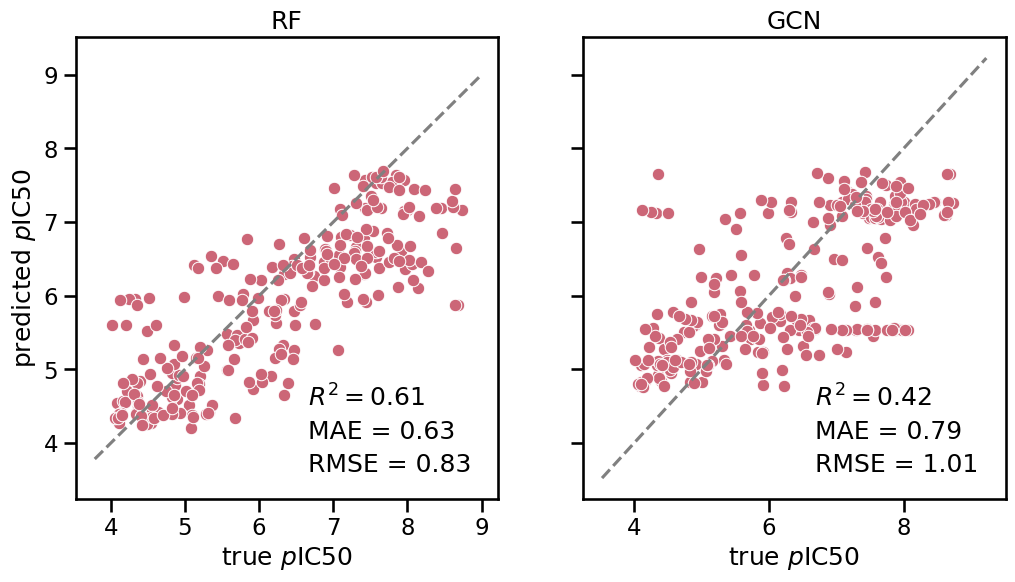

In [75]:
# Performance Figures
import numpy as np
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for idx, model in enumerate(["RF", "GCN"]):
    df_tmp = df_pot.query('model == @model')
    sns.scatterplot(df_tmp,
                    x='y_true',
                    y='y_pred',
                    ax=axs[idx])
    axs[idx].set_title(model)
    axs[idx].set_xlabel('true $p$IC50')
    axs[idx].set_ylabel('predicted $p$IC50')
    # add diagonal

    min_val = np.min([axs[idx].get_xlim()[0], axs[idx].get_ylim()[0]])
    max_val = np.max([axs[idx].get_xlim()[1], axs[idx].get_ylim()[1]])
    axs[idx].plot([min_val, max_val], [min_val, max_val], c='gray', ls='--')

    # some metrics in the graph
    r2 = r2_score(y_true=df_tmp.y_true, y_pred=df_tmp.y_pred)
    rmse = root_mean_squared_error(y_true=df_tmp.y_true, y_pred=df_tmp.y_pred)
    mae = mean_absolute_error(y_true=df_tmp.y_true, y_pred=df_tmp.y_pred)

    x_text = 0.55
    y_text = 0.2
    y_delta = 0.07
    axs[idx].text(x=x_text,
                  y=y_text,
                  transform=axs[idx].transAxes,
                  s='$R^2 = $' + f'{r2:.2f}')
    axs[idx].text(x=x_text,
                  y=y_text-y_delta,
                  transform=axs[idx].transAxes,
                  s='MAE = ' + f'{mae:.2f}')
    axs[idx].text(x=x_text,
                  y=y_text-2*y_delta,
                  transform=axs[idx].transAxes,
                  s='RMSE = ' + f'{rmse:.2f}')


In [88]:
# Dummy predictor
y_true = df_tmp.y_pred.to_list()
y_train_mean = df_train.pIC50.mean()
y_pred_dummy = [y_train_mean for _ in y_true]

metrics = [r2_score, root_mean_squared_error, mean_absolute_error]
metric_names = ['R^2', 'RMSE', 'MAE']
for m, n in zip(metrics, metric_names):
    print(n, f'{m(y_true=y_true, y_pred=y_pred_dummy):.3f}')


R^2 -0.771
RMSE 1.215
MAE 0.928


Text(0, 0.5, '# of fragments')

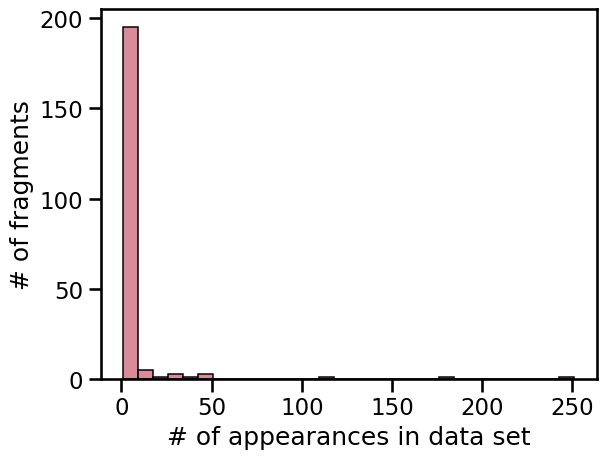

In [22]:
model = "GCN"

df_plot = df_fragments.loc[df_fragments.model == model]

fig, axs = plt.subplots(1, 1)
# plot histogram
sns.histplot(data=df_plot,
             x='len',
             ax=axs)
axs.set_xlabel('# of appearances in data set')
axs.set_ylabel('# of fragments')

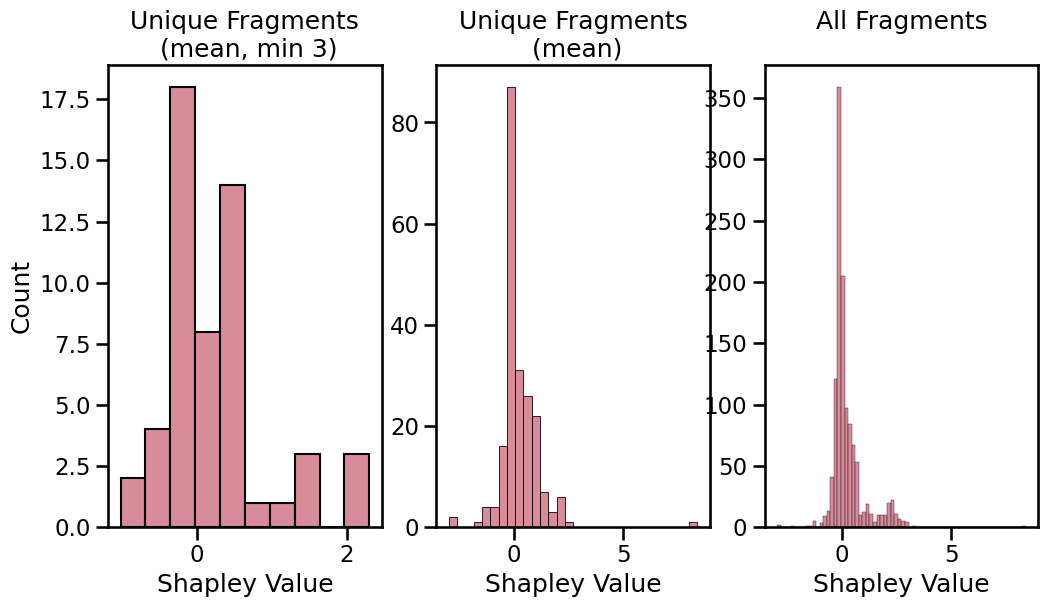

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(12, 6))
min = 3

sns.histplot(x=df_plot.loc[df_plot.len >= min]["mean"].to_list(),
            ax=axs[0])
axs[0].set_title(f'Unique Fragments\n (mean, min {min})')
sns.histplot(x=df_plot["mean"].to_list(),
            ax=axs[1])
axs[1].set_title('Unique Fragments\n (mean)')
sns.histplot(x=df_plot.explode("list").list.to_list(),
             ax=axs[2])
axs[2].set_title('All Fragments\n')

for ax in axs[1:]:
    ax.set_ylabel("")
for ax in axs:
    ax.set_xlabel('Shapley Value')

In [24]:
df_pot.loc[df_pot.model == model].fragExplainer_expected_value.unique()

array([5.02353525])

In [25]:
# try generating fingerprints and then clustering using tsne?
from rdkit.Chem import rdFingerprintGenerator
import numpy as np

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

fragments = df_plot.loc[df_plot.len >= min].fragments.to_list()
mols = [MolFromSmiles(smiles) for smiles in fragments]
fps = np.stack([mfpgen.GetCountFingerprintAsNumPy(mol) for mol in mols])

values = df_plot.loc[df_plot.len >= min]['mean'].to_list()

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2,
            perplexity=30)
red_dim = tsne.fit_transform(fps)

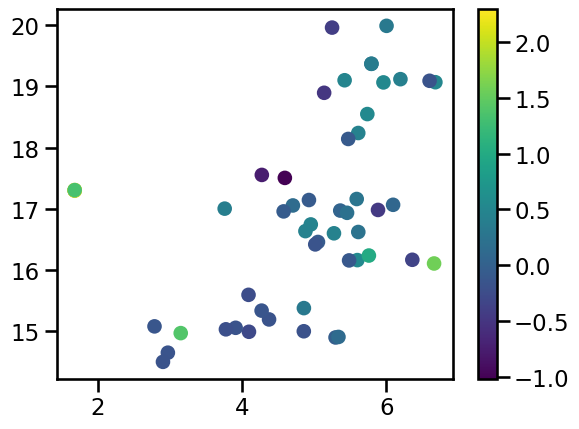

In [26]:
plt.scatter(x=red_dim[:,0],
            y=red_dim[:,1],
            c=values)
plt.colorbar()

In [27]:
sm = df_pot.query('model == "RF" and y_true > 7 and y_pred > 7').iloc[0].smiles

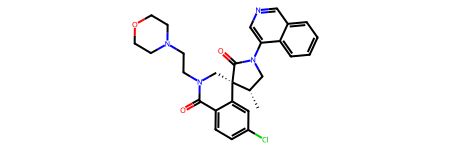

In [28]:
MolFromSmiles(sm)

In [29]:
sm

'C[C@H]1CN(c2cncc3ccccc23)C(=O)[C@@]12CN(CCN1CCOCC1)C(=O)c1ccc(Cl)cc12'

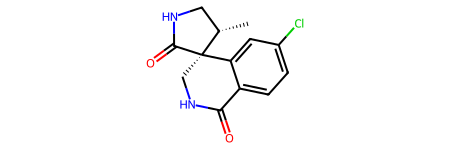

In [30]:
mod_sm = 'C[C@H]1CNC(=O)[C@@]12CNC(=O)c1ccc(Cl)cc12'
MolFromSmiles(mod_sm)